In [1]:
!apt-get update && apt-get install -y libvulkan1

Get:1 https://cli.github.com/packages stable InRelease [4,685 B]
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:4 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:5 https://cli.github.com/packages stable/main amd64 Packages [355 B]
Hit:6 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:7 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [112 kB]
Get:8 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:9 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [4,251 kB]
Get:10 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages [1,315 kB]
Get:11 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [3,175 kB]
Get:12 http://security.ubuntu.com/ubuntu jammy-security/restricted amd64 Packages [7,658 kB]
Get:13 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB

In [2]:
!pip install -q pymupdf pandas sentence-transformers scikit-learn langchain-core langchain-openai langchain-text-splitters nltk langgraph requests tqdm "unstructured[all-docs]" pillow lxml pillow huggingface_hub litert-lm-api ai-edge-litert

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 12.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 21.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 4.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 6.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.4/62.4 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.8/25.8 MB 60.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.1/125.1 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 570.0/570.0 kB 21.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.8/46.8 MB 24.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━

In [8]:
from dotenv import load_dotenv
load_dotenv("api_key.env")

True

In [4]:
import os
import time
import base64
import io
import pymupdf
import pandas as pd
import nltk
import numpy as np
import operator
import re
import requests
from typing import List, Dict, Any, TypedDict, Union, Annotated
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import tempfile
from tqdm import tqdm
from unstructured.partition.pdf import partition_pdf

from IPython.display import display, HTML, Image as IPImage

from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage
from langchain_core.prompts import ChatPromptTemplate
from langchain_text_splitters import NLTKTextSplitter

from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, END

In [5]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [6]:
# 2. Download the model using the Python API
import os
from huggingface_hub import hf_hub_download
from huggingface_hub import snapshot_download
import litert_lm

In [9]:
# Replace with your actual Hugging Face token
HF_TOKEN = os.environ["HF_TOKEN"]

print("Downloading LiteRT E4B model from Hugging Face...")
os.makedirs("/content/models", exist_ok=True)

model_name = "gemma-4-E4B-it"
model_id = f"litert-community/{model_name}-litert-lm"

# Note: Update the repo_id and filename to the exact multimodal LiteRT
# model you have accepted the license for on Hugging Face.
model_path = snapshot_download(
    repo_id=model_id,
    local_dir="/content/models",
    token=HF_TOKEN
)

full_model_file_path = os.path.join(model_path, f"{model_name}.litertlm")

print(f"Model downloaded successfully to: {model_path}")

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 8 files:   0%|          | 0/8 [00:00<?, ?it/s]

Model downloaded successfully to: /content/models


In [10]:
api_base_url = "https://openrouter.ai/api/v1"
ocr_model_name = "openrouter/free"
embedding_model_name = "all-MiniLM-L6-v2"
genai_model_name = "nvidia/nemotron-3.5-lightning:free"

openrouter_api_key = os.environ["OPENROUTER_API_KEY"]

In [11]:
embedding_model = SentenceTransformer(embedding_model_name)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

# PDF PARSING

In [12]:
def robust_invoke(chain, inputs, max_retries=5, base_delay=15):
    """Executes LLM calls with exponential backoff on 429 rate limits."""
    for attempt in range(max_retries):
        try:
            return chain.invoke(inputs)
        except Exception as e:
            if "429" in str(e):
                wait_time = base_delay * (attempt + 1)
                print(f"\n⚠️ Rate limit encountered. Pausing for {wait_time}s (Attempt {attempt + 1}/{max_retries})...")
                time.sleep(wait_time)
            else:
                raise e
    raise TimeoutError("Exceeded maximum retry attempts due to API rate limits.")

In [13]:
def reconstruct_element(df_row: pd.Series):
    """Pass a DataFrame row to this function to visualize its raw Image or Table."""
    if df_row['type'] == 'table' and pd.notna(df_row.get('raw_html')):
        print(f"--- Reconstructing Table from Page {df_row['page_number']} ---")
        display(HTML(df_row['raw_html']))
    elif df_row['type'] == 'image_summary' and pd.notna(df_row.get('raw_base64')):
        print(f"--- Reconstructing Image from Page {df_row['page_number']} ---")
        image_data = base64.b64decode(df_row['raw_base64'])
        display(IPImage(data=image_data))
    else:
        print(f"--- Text Content from Page {df_row['page_number']} ---")
        print(df_row['content'])

In [42]:
# ==========================================
# 1. Pure CPU PDF Processor (LiteRT-LM + Gemma)
# ==========================================
class PDFProcessor:
    def __init__(self, model_path: str, chunk_size: int = 1000, chunk_overlap: int = 200):
        self.model_path = model_path

        self.text_splitter = NLTKTextSplitter(
            chunk_size=chunk_size,
            chunk_overlap=chunk_overlap
        )
        print("Initialized Processor. LLM will load dynamically during execution to save memory.")

    def process_pdf(self, pdf_source: str, max_pages: int) -> pd.DataFrame:
        data = []

        with tempfile.TemporaryDirectory() as temp_dir:
            # Step 1: Download / Locate File
            if pdf_source.startswith(("http://", "https://", "www")):
                print(f"\n[1/4] 📥 Downloading PDF from: {pdf_source}")
                response = requests.get(pdf_source, stream=True)
                response.raise_for_status()

                pdf_path = os.path.join(temp_dir, "document.pdf")
                total_size = int(response.headers.get('content-length', 0))
                with open(pdf_path, "wb") as f, tqdm(
                    desc="Downloading",
                    total=total_size,
                    unit='iB',
                    unit_scale=True,
                    unit_divisor=1024,
                ) as bar:
                    for chunk in response.iter_content(chunk_size=1024):
                        size = f.write(chunk)
                        bar.update(size)
            else:
                print(f"\n[1/4] 📂 Loading local PDF: {pdf_source}")
                pdf_path = pdf_source

            # Step 2: Document Layout Partitioning
            print("\n[2/4] 🧠 Running AI Layout Analysis...")
            start_time = time.time()

            elements = partition_pdf(
                filename=pdf_path,
                strategy="hi_res",
                infer_table_structure=True,
                extract_images_in_pdf=True,
                extract_image_block_output_dir=temp_dir
            )
            elapsed = round(time.time() - start_time, 2)
            print(f"✅ Layout analyzed in {elapsed}s. Found {len(elements)} structural blocks.")

            # Step 3: LLM Inference via LiteRT-LM
            print("\n[3/4] 🤖 Loading LiteRT-LM Engine into CPU RAM...")

            with litert_lm.Engine(
                self.model_path,
                backend=litert_lm.Backend.CPU(),
                vision_backend=litert_lm.Backend.CPU()
            ) as engine:

                print("✅ Engine Loaded! Processing text blocks, tables, and analyzing images...")

                text_accumulator = []
                current_page = 1
                page_chunk_counter = 0
                page_paragraph_counter = 0

                def flush_text_accumulator(page_n, meta):
                    nonlocal page_chunk_counter, page_paragraph_counter
                    if text_accumulator:
                        combined_text = " ".join(text_accumulator)
                        chunks = self.text_splitter.split_text(combined_text)

                        for i, chunk in enumerate(chunks):
                            data.append({
                                "id": f"page_{page_n}_text_{page_paragraph_counter}_part_{i}",
                                "type": "text",
                                "content": chunk,
                                "length": len(chunk),
                                "page_number": page_n,
                                "chunk_number": page_chunk_counter,
                                "raw_html": None,
                                "metadata": meta
                            })
                            page_chunk_counter += 1

                        page_paragraph_counter += 1
                        text_accumulator.clear()

                for idx, element in enumerate(tqdm(elements, desc="Processing Elements")):
                    page_num = element.metadata.page_number if (element.metadata and hasattr(element.metadata, 'page_number')) else current_page

                    if page_num > max_pages:
                        break

                    if page_num != current_page:
                        flush_text_accumulator(current_page, {"page": current_page, "source": pdf_source})
                        current_page = page_num
                        page_chunk_counter = 0
                        page_paragraph_counter = 0

                    base_metadata = {"page": page_num, "source": pdf_source}
                    category = element.category

                    if category in ["Header", "Footer", "PageNumber"]:
                        continue

                    if category == "Table":
                        flush_text_accumulator(page_num, base_metadata)
                        table_content = element.metadata.text_as_html if (element.metadata and hasattr(element.metadata, 'text_as_html') and element.metadata.text_as_html) else element.text

                        table_summary = ""

                        # UPDATED: Convert HTML to Markdown + Summary for optimal vector search
                        if "<table" in table_content:
                            try:
                                with engine.create_conversation() as conversation:
                                    prompt = (
                                        "<start_of_turn>user\n"
                                        "You are a data processing assistant. I will provide an HTML table extracted from a document.\n"
                                        "Please do two things:\n"
                                        "1. Write a 1-2 sentence descriptive summary of what this table shows.\n"
                                        "2. Convert the table data into a clean Markdown table format.\n"
                                        "Output ONLY the summary followed by the Markdown table. Do not include any HTML tags.\n\n"
                                        f"Raw HTML:\n{table_content}<end_of_turn>\n"
                                        "<start_of_turn>model\n"
                                    )
                                    response = conversation.send_message(prompt)
                                    table_summary = response["content"][0]["text"].strip()
                            except Exception as e:
                                print(f"\n[Warning] Could not process table on page {page_num}: {e}")
                                table_summary = table_content
                        else:
                            table_summary = table_content

                        data.append({
                            "id": f"page_{page_num}_table_{page_chunk_counter}",
                            "type": "table",
                            # Vector DB embeds 'content'. The summary + markdown makes it highly searchable.
                            "content": f"Table Information:\n{table_summary}",
                            "length": len(table_summary),
                            "page_number": page_num,
                            "chunk_number": page_chunk_counter,
                            "raw_html": table_content, # Keep raw HTML in case you need it later
                            "metadata": base_metadata
                        })
                        page_chunk_counter += 1

                    elif category in ["Image", "Figure"]:
                        flush_text_accumulator(page_num, base_metadata)
                        image_path = element.metadata.image_path if (element.metadata and hasattr(element.metadata, 'image_path')) else None

                        if image_path and os.path.exists(image_path):
                            try:
                                # 1. Multimodal Inference via LiteRT-LM (using the fast local path)
                                with engine.create_conversation() as conversation:
                                    response = conversation.send_message(
                                        litert_lm.Contents.of(
                                            "Describe this image in detail. If it is a chart or graph, summarize the data.",
                                            litert_lm.Content.ImageFile(absolute_path=image_path)
                                        )
                                    )
                                    summary = response["content"][0]["text"].strip()

                                # 2. Convert to Base64 for persistent storage in the DataFrame
                                with open(image_path, "rb") as img_file:
                                    b64_data = base64.b64encode(img_file.read()).decode('utf-8')
                                    # Formatted for easy rendering in HTML/Markdown UIs
                                    raw_base64 = f"data:image/jpeg;base64,{b64_data}"

                                data.append({
                                    "id": f"page_{page_num}_img_{page_chunk_counter}",
                                    "type": "image_summary",
                                    "content": f"Image/Chart Summary:\n{summary}",
                                    "length": len(summary),
                                    "page_number": page_num,
                                    "chunk_number": page_chunk_counter,
                                    "raw_html": None,
                                    "raw_base64": raw_base64,
                                    "metadata": base_metadata
                                })
                                page_chunk_counter += 1
                            except Exception as e:
                                print(f"\n[Warning] Could not process image on page {page_num}: {e}")

                    else:
                        text = element.text.strip()
                        if len(text) < 4 and not any(c.isalpha() for c in text):
                            continue
                        if text:
                            text_accumulator.append(text)

                flush_text_accumulator(current_page, {"page": current_page, "source": pdf_source})

        print(f"\n[4/4] 📦 Finished! Created {len(data)} clean vector chunks.\n")
        return pd.DataFrame(data)

In [ ]:
print("Step 1: Parsing PDF & Images...")
processor = PDFProcessor(model_path=full_model_file_path)
url = "https://arxiv.org/pdf/2008.07779"
df = processor.process_pdf(pdf_source = url, max_pages = 3)
print(f"Extracted {len(df)} chunks.")

Step 1: Parsing PDF & Images...
Initialized Processor. LLM will load dynamically during execution to save memory.

[1/4] 📥 Downloading PDF from: https://arxiv.org/pdf/2008.07779


Downloading: 100%|██████████| 596k/596k [00:00<00:00, 7.79MiB/s]



[2/4] 🧠 Running AI Layout Analysis...


✅ Layout analyzed in 55.84s. Found 118 structural blocks.

[3/4] 🤖 Loading LiteRT-LM Engine into CPU RAM...
✅ Engine Loaded! Processing text blocks, tables, and analyzing images...


Processing Elements:   0%|          | 0/118 [00:00<?, ?it/s]

In [44]:
df

,id,type,content,length,page_number,chunk_number,raw_html,metadata
0,page_1_text_0_part_0,text,2020 v arX1V i X r a Predicting Future Sales o...,923,1,0,None,"{'page': 1, 'source': 'https://arxiv.org/pdf/2..."
1,page_1_text_0_part_1,text,"In this project, we worked with a challenging ...",921,1,1,None,"{'page': 1, 'source': 'https://arxiv.org/pdf/2..."
2,page_1_text_0_part_2,text,1 Introduction Accurate sales forecasting is o...,992,1,2,None,"{'page': 1, 'source': 'https://arxiv.org/pdf/2..."
3,page_1_text_0_part_3,text,A time series is a sequence of historical meas...,442,1,3,None,"{'page': 1, 'source': 'https://arxiv.org/pdf/2..."
4,page_2_text_0_part_0,text,need to forecast the total sales of every prod...,974,2,0,None,"{'page': 2, 'source': 'https://arxiv.org/pdf/2..."
5,page_2_text_0_part_1,text,Another group searched for what can be some no...,882,2,1,None,"{'page': 2, 'source': 'https://arxiv.org/pdf/2..."
6,page_2_text_0_part_2,text,"[4] As the name says, the blog is about compar...",929,2,2,None,"{'page': 2, 'source': 'https://arxiv.org/pdf/2..."
7,page_2_text_0_part_3,text,"Meanwhile, we found another interesting paper ...",931,2,3,None,"{'page': 2, 'source': 'https://arxiv.org/pdf/2..."
8,page_2_text_0_part_4,text,And this gap was ﬁlled by another well articul...,593,2,4,None,"{'page': 2, 'source': 'https://arxiv.org/pdf/2..."


In [45]:
df[["page_number", "type"]].value_counts().sort_index()

,,count
page_number,type,
1,text,4
2,text,5


In [19]:
df["type"].value_counts()

,count
type,
text,24
image_summary,4
table,3


In [20]:
df.iloc[10]["content"]

'Figure 1: LSTM-based neural network architecture, combining static and dynamic features we did, our approach was to either remove it completely or to interpret the values by taking mean or median.\n\nWe took the most appropriate approach on a case by case basis.\n\n3.2 Exploratory Data Analysis (EDA) To get a lead for the features to derive, EDA was a required step.\n\nThe plots which gave us pretty good lead for data preparation and feature extraction are shown in ﬁgure 2.\n\nWe noticed some key observations that we applied during feature engineering process.\n\nThe most important ﬁnding was that the trend is normally distributed with just few peaks in between which are observed yearly (useful for getting intuition of extracting time lag).\n\nSome other observations we noticed were that sales is highest during weekends so features that might be helpful to capture the effect might be a count of each of the weekday in the date-block, and count of weekends.'

In [21]:
df[df["type"] == "table"]

,id,type,content,length,page_number,chunk_number,raw_html,metadata
18,page_4_table_3,table,Table Information:\nThis table lists several h...,449,4,3,<table><thead><tr><th>Parameters eta</th><th>D...,"{'page': 4, 'source': 'https://arxiv.org/pdf/2..."
25,page_6_table_1,table,Table Information:\nThis table compares the pe...,382,6,1,<table><tbody><tr><td>| LSTM</td><td>0.804657<...,"{'page': 6, 'source': 'https://arxiv.org/pdf/2..."
27,page_6_table_3,table,Table Information:\nThis table presents a comp...,462,6,3,<table><thead><tr><th>Features item_id</th><th...,"{'page': 6, 'source': 'https://arxiv.org/pdf/2..."


In [22]:
row_to_show = df.iloc[18]
reconstruct_element(row_to_show)

--- Reconstructing Table from Page 4 ---


Parameters eta,Description Learning Rate,Optimal Value 0.148
max_depth,Maximum depth of the tree,6
min_child_weight |,Minimum sum of weight of observation in a child,26
lambda,L2 regularization term on weights,0.171


In [35]:
df.iloc[18]['content']

'Table Information:\nThis table lists several hyperparameters for a machine learning model, detailing their descriptions and optimal values. It covers parameters such as maximum depth, minimum child weight, and L2 regularization.\n\n| Parameters eta | Description | Optimal Value |\n|---|---|---|\n| max_depth | Maximum depth of the tree | 6 |\n| min_child_weight | Minimum sum of weight of observation in a child | 26 |\n| lambda | L2 regularization term on weights | 0.171 |'

In [24]:
df[df["type"] == "image_summary"]

,id,type,content,length,page_number,chunk_number,raw_html,metadata
9,page_3_img_0,image_summary,Image/Chart Summary:\nThis image is a **diagra...,3042,3,0,None,"{'page': 3, 'source': 'https://arxiv.org/pdf/2..."
12,page_3_img_3,image_summary,Image/Chart Summary:\nThis is a **grouped bar ...,2021,3,3,None,"{'page': 3, 'source': 'https://arxiv.org/pdf/2..."
13,page_3_img_4,image_summary,Image/Chart Summary:\nThis image is a **bar ch...,1809,3,4,None,"{'page': 3, 'source': 'https://arxiv.org/pdf/2..."
22,page_5_img_2,image_summary,Image/Chart Summary:\nThis image is a **diagra...,3510,5,2,None,"{'page': 5, 'source': 'https://arxiv.org/pdf/2..."


In [36]:
row_to_show = df.iloc[9]
reconstruct_element(row_to_show)

--- Text Content from Page 3 ---
Image/Chart Summary:
This image is a **diagram illustrating the architecture of a neural network model**, likely designed for time series forecasting or prediction. It is not a chart or graph displaying data, but rather a schematic of a computational model.

Here is a detailed description of the components and the flow of information:

### Overall Structure
The diagram follows a top-down flow, starting from the input features at the bottom and progressing through several layers of processing to arrive at the final prediction at the top.

### Input Layer (Bottom)
The model takes several distinct types of input features, which are processed through different initial pathways:

1.  **Static Information:** This is processed through a pathway involving:
    *   **Static information - word2vec features:** These are fed into a block of **Stacked dense layers**.
    *   **Item super category - one hot feature:** This is also fed into a block of **Stacked dense 

# VECTOR DB CREATION (LOCAL)

In [26]:
# ==========================================
# 2. Local Vector Database (DataFrame-based)
# ==========================================
class LocalVectorDB:
    def __init__(self):
        self.model = embedding_model
        self.df = None
        self.embeddings = None

    def index_dataframe(self, df: pd.DataFrame):
        self.df = df
        print("Computing embeddings for vector search...")
        self.embeddings = self.model.encode(df['content'].tolist(), show_progress_bar=True)

    def search(self, query: str, top_k: int = 3, threshold: float = 0.3) -> List[Dict[str, Any]]:
        query_emb = self.model.encode([query])
        similarities = cosine_similarity(query_emb, self.embeddings)[0]

        # Sort indices by highest similarity score first
        top_indices = np.argsort(similarities)[::-1][:top_k]

        results = []
        for idx in top_indices:
            score = similarities[idx]

            # Only include results that meet the minimum similarity threshold
            if score >= threshold:
                row = self.df.iloc[idx]
                results.append({
                    "content": row["content"],
                    "metadata": row["metadata"],
                    "type": row["type"],
                    "score": score
                })
            else:
                # Since results are sorted in descending order, the moment we hit
                # a score below the threshold, all subsequent scores will also fail.
                break

        return results

In [27]:
print("\nStep 2: Building Local VectorDB...")
vector_db = LocalVectorDB()
vector_db.index_dataframe(df)


Step 2: Building Local VectorDB...
Computing embeddings for vector search...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

# LANGGRAPH SETUP

In [28]:
# ==========================================
# 3. LangGraph Agent Setup
# ==========================================
class GraphState(TypedDict):
    question: str
    generation: str
    documents: List[Dict[str, Any]]
    iterations: Annotated[int, operator.add]

In [29]:
def run_litert_inference(engine: litert_lm.Engine, prompt: str) -> str:
    """Helper to run synchronous text inference through LiteRT-LM conversation."""
    with engine.create_conversation() as conversation:
        response = conversation.send_message(prompt)
        return response["content"][0]["text"].strip()

In [30]:
def is_yes(text: str) -> bool:
    """Extracts a 'yes' from chatty edge models."""
    # Remove punctuation and markdown, convert to lowercase
    clean_text = re.sub(r'[^a-zA-Z\s]', '', text).lower().strip()
    # Check if 'yes' appears in the first few words
    return 'yes' in clean_text.split()[:5]

In [31]:
def create_agentic_rag(vector_db, model_or_path: Union[str, litert_lm.Engine], max_iterations = 1):

    if isinstance(model_or_path, str):
        engine = litert_lm.Engine(model_or_path, backend=litert_lm.Backend.CPU())
    else:
        engine = model_or_path

    # ==========================================
    # 2. LangGraph Node Definitions
    # ==========================================
    def retrieve(state: GraphState):
        question = state["question"]
        iterations = state.get("iterations", 0)

        print(f"\n[{iterations}] 🔎 RETRIEVING CONTEXT")
        print(f"   Query: '{question}'")

        docs = vector_db.search(question, top_k=4, threshold=0.3)
        print(f"   Result: Retrieved {len(docs)} chunks from vector DB.")

        return {"documents": docs, "question": question}

    def grade_documents(state: GraphState):
        print(f"\n[{state.get('iterations', 0)}] ⚖️ GRADING DOCUMENT RELEVANCE")
        question = state["question"]
        documents = state["documents"]
        filtered_docs = []

        for i, d in enumerate(documents):
            prompt = (
                "<start_of_turn>user\n"
                "Evaluate if the document contains facts relevant to the user question.\n"
                f"Document: {d['content'][:500]}...\n"
                f"Question: {question}\n\n"
                "Respond with ONLY the word 'yes' or 'no'.<end_of_turn>\n"
                "<start_of_turn>model\n"
            )
            score = run_litert_inference(engine, prompt)

            if is_yes(score):
                filtered_docs.append(d)

        print(f"   Result: Kept {len(filtered_docs)} docs (Discarded {len(documents) - len(filtered_docs)}).")
        return {"documents": filtered_docs, "question": question}

    def generate(state: GraphState):
        print(f"\n[{state.get('iterations', 0)}] 💡 GENERATING ANSWER")
        question = state["question"]
        documents = state["documents"]
        context = "\n\n---\n\n".join([d["content"] for d in documents])

        prompt = (
            "<start_of_turn>user\n"
            "You are an assistant for question-answering tasks. Use ONLY the following retrieved context to answer the question.\n"
            "If the answer cannot be found in the context, output EXACTLY this phrase and nothing else: 'NOT_FOUND'\n"
            "Otherwise, keep the response accurate and concise.\n\n"
            f"Context:\n{context}\n\n"
            f"Question: {question}<end_of_turn>\n"
            "<start_of_turn>model\n"
        )
        generation = run_litert_inference(engine, prompt)
        print(f"   Result: Generated response ({len(generation)} chars).")

        return {"generation": generation}

    def rewrite_query(state: GraphState):
        print(f"\n[{state.get('iterations', 0)}] 🔄 REWRITING QUERY")
        question = state["question"]

        prompt = (
            "<start_of_turn>user\n"
            "Rewrite the following search query to improve semantic vector database retrieval. "
            "Focus on extracting core keywords and intent. Output ONLY the rewritten query text, nothing else.\n\n"
            f"Initial query: {question}<end_of_turn>\n"
            "<start_of_turn>model\n"
        )
        new_question = run_litert_inference(engine, prompt).strip()
        print(f"   New Query: '{new_question}'")

        return {"question": new_question, "iterations": 1}

    def query_not_relevant(state: GraphState):
        print(f"\n[{state.get('iterations', 0)}] 🚫 IRRELEVANT QUERY DETECTED")
        msg = "Query not relevant to the uploaded document."
        return {"generation": msg}

    # ==========================================
    # 3. Conditional Decision Logic
    # ==========================================

    # NEW: Short-circuits the grader if the vector DB returns nothing above threshold
    def decide_to_grade(state: GraphState):
        if not state.get("documents"):
            if state.get("iterations", 0) >= max_iterations:
                print("   ⚠️ Max iterations reached with 0 retrieved documents. Flagging as irrelevant.")
                return "Irrelevant -> End"
            print("   ❌ 0 documents retrieved -> Re-routing to query rewriter.")
            return "No Docs -> Rewrite"
        return "Docs Found -> Grade"

    # EXISTING: Catches documents that vector DB thought were good, but LLM grader rejected
    def decide_to_generate(state: GraphState):
        if not state.get("documents"):
            if state.get("iterations", 0) >= max_iterations:
                print("   ⚠️ Max iterations reached after LLM grading. Flagging as irrelevant.")
                return "Irrelevant -> End"
            print("   ❌ All documents failed grading -> Re-routing to query rewriter.")
            return "No Docs -> Rewrite"
        return "Docs Passed -> Generate"

    def verify_and_route(state: GraphState):
        print(f"\n[{state.get('iterations', 0)}] 🧐 VERIFYING ANSWER")

        if "NOT_FOUND" in state.get("generation", ""):
            print("   ✅ Generation yielded NOT_FOUND flag. Routing to fallback node.")
            return "Irrelevant -> End"

        if state.get("iterations", 0) >= max_iterations:
            print("   ⚠️ Max iterations reached. Terminating loop and returning best effort.")
            return "Max Retries Reached"

        context = "\n".join([d["content"] for d in state["documents"]])
        generation = state["generation"]
        question = state["question"]

        hallucination_prompt = (
            "<start_of_turn>user\n"
            f"Facts:\n{context}\n\n"
            f"Answer:\n{generation}\n\n"
            "Is the answer strictly supported by the provided facts? "
            "Respond with ONLY the word 'yes' or 'no'.<end_of_turn>\n"
            "<start_of_turn>model\n"
        )
        grounded = run_litert_inference(engine, hallucination_prompt)

        if is_yes(grounded):
            relevance_prompt = (
                "<start_of_turn>user\n"
                f"Question: {question}\n\n"
                f"Answer: {generation}\n\n"
                "Does the answer directly address and resolve the user question? "
                "Respond with ONLY the word 'yes' or 'no'.<end_of_turn>\n"
                "<start_of_turn>model\n"
            )
            answers_q = run_litert_inference(engine, relevance_prompt)

            if is_yes(answers_q):
                print("   ✅ Answer is verified and complete.")
                return "Valid & Complete -> END"

        print("   ❌ Verification failed -> Re-writing query and re-trying.")
        return "Failed Check -> Rewrite"

    # ==========================================
    # 4. Graph Construction & Compilation
    # ==========================================
    workflow = StateGraph(GraphState)

    workflow.add_node("retrieve", retrieve)
    workflow.add_node("grade_documents", grade_documents)
    workflow.add_node("generate", generate)
    workflow.add_node("rewrite_query", rewrite_query)
    workflow.add_node("query_not_relevant", query_not_relevant)

    workflow.set_entry_point("retrieve")

    # FIXED: Replaced standard edge with the new conditional router
    workflow.add_conditional_edges(
        "retrieve",
        decide_to_grade,
        {
            "No Docs -> Rewrite": "rewrite_query",
            "Docs Found -> Grade": "grade_documents",
            "Irrelevant -> End": "query_not_relevant"
        }
    )

    workflow.add_conditional_edges(
        "grade_documents",
        decide_to_generate,
        {
            "No Docs -> Rewrite": "rewrite_query",
            "Docs Passed -> Generate": "generate",
            "Irrelevant -> End": "query_not_relevant"
        }
    )

    workflow.add_conditional_edges(
        "generate",
        verify_and_route,
        {
            "Valid & Complete -> END": END,
            "Failed Check -> Rewrite": "rewrite_query",
            "Max Retries Reached": END,
            "Irrelevant -> End": "query_not_relevant"
        }
    )

    workflow.add_edge("rewrite_query", "retrieve")
    workflow.add_edge("query_not_relevant", END)

    return workflow.compile()

In [32]:
app = create_agentic_rag(vector_db, full_model_file_path)

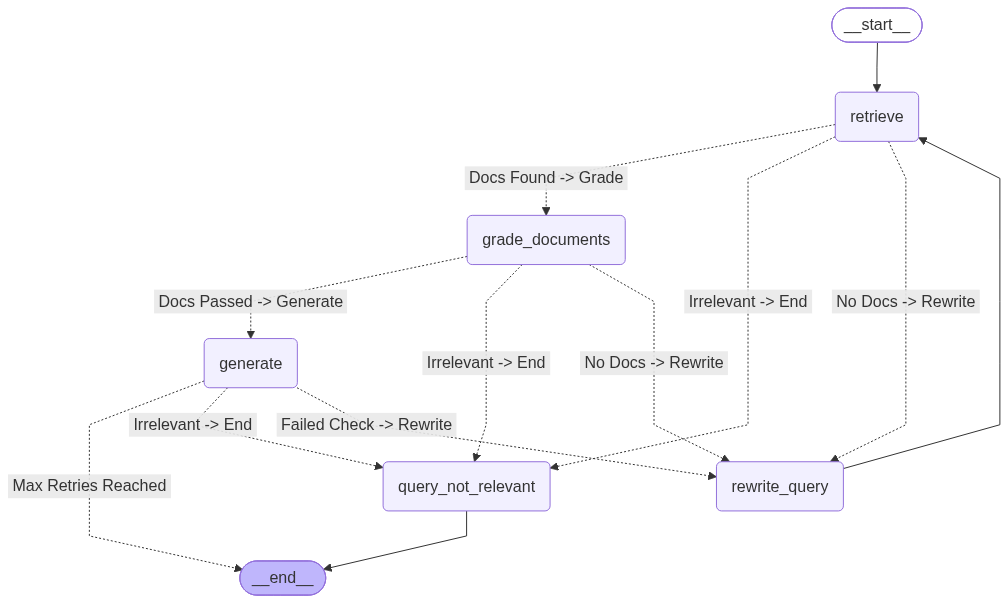

In [33]:
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

# FINAL EXECUTION

In [34]:
# 3. Query the system
inputs = {"question": "Whats the weather in Tokyo today?"}
# inputs = {"question": "What problem is this paper trying to solve?"}

print("Starting Agentic RAG Pipeline...")

# Variable to hold the final state of the graph
final_state = None

# Run the graph ONCE using stream
for output in app.stream(inputs):
    for key, value in output.items():
        print(f"--- (LangGraph) Completed node: {key} ---")
        # Save the state output of the most recently completed node
        final_state = value

# 4. Print the final results
print("\n" + "="*40)
print("FINAL GROUNDED ANSWER:")
print("="*40)

if final_state and "generation" in final_state:
    print(final_state["generation"])
else:
    print("Agent failed to generate an answer within the iteration limit.")

Starting Agentic RAG Pipeline...

[0] 🔎 RETRIEVING CONTEXT
   Query: 'Whats the weather in Tokyo today?'
   Result: Retrieved 0 chunks from vector DB.
   ❌ 0 documents retrieved -> Re-routing to query rewriter.
--- (LangGraph) Completed node: retrieve ---

[0] 🔄 REWRITING QUERY
   New Query: 'Tokyo weather forecast today'
--- (LangGraph) Completed node: rewrite_query ---

[1] 🔎 RETRIEVING CONTEXT
   Query: 'Tokyo weather forecast today'
   Result: Retrieved 0 chunks from vector DB.
   ⚠️ Max iterations reached with 0 retrieved documents. Flagging as irrelevant.
--- (LangGraph) Completed node: retrieve ---

[1] 🚫 IRRELEVANT QUERY DETECTED
--- (LangGraph) Completed node: query_not_relevant ---

FINAL GROUNDED ANSWER:
Query not relevant to the uploaded document.
